In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:
root = "bitdance"
from qwen3 import Qwen3ForCausalLM
text_encoder = Qwen3ForCausalLM.from_pretrained(root, subfolder="text_encoder")

/home/wg25r/miniconda/envs/neg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 443/443 [00:00<00:00, 6959.19it/s]


In [3]:
import torch
from diffusers import DiffusionPipeline
import sys
sys.path.append(root)
pipe = DiffusionPipeline.from_pretrained(
    root,
    custom_pipeline=root,
    text_encoder=text_encoder,
    torch_dtype=torch.bfloat16,
).to("cuda")


Loading pipeline components...: 100%|██████████| 5/5 [00:01<00:00,  4.61it/s]


In [32]:
result = pipe(
    prompt = "In a surreal, blurry dreamscape, a massively oversaturated crimson apple dominates, towering over a tiny, jagged-edged azure house. The scene is illogical with conflicting scales, drenched in excessively vivid, burning colors that lose detail, and all curved lines, like winding paths, display clear aliasing with staircase edges.",
    neg_prompt = "A sharp, realistic composition with consistently scaled objects, naturally balanced colors, and smooth, anti-aliased edges.",
    height=1024,
    width=1024,
    num_inference_steps=20,
    guidance_scale=20.0,
    show_progress_bar=True
)

Initial hidden_c shape: torch.Size([1, 64, 5120])


Decoding steps: 100%|██████████| 64/64 [00:18<00:00,  3.45it/s]


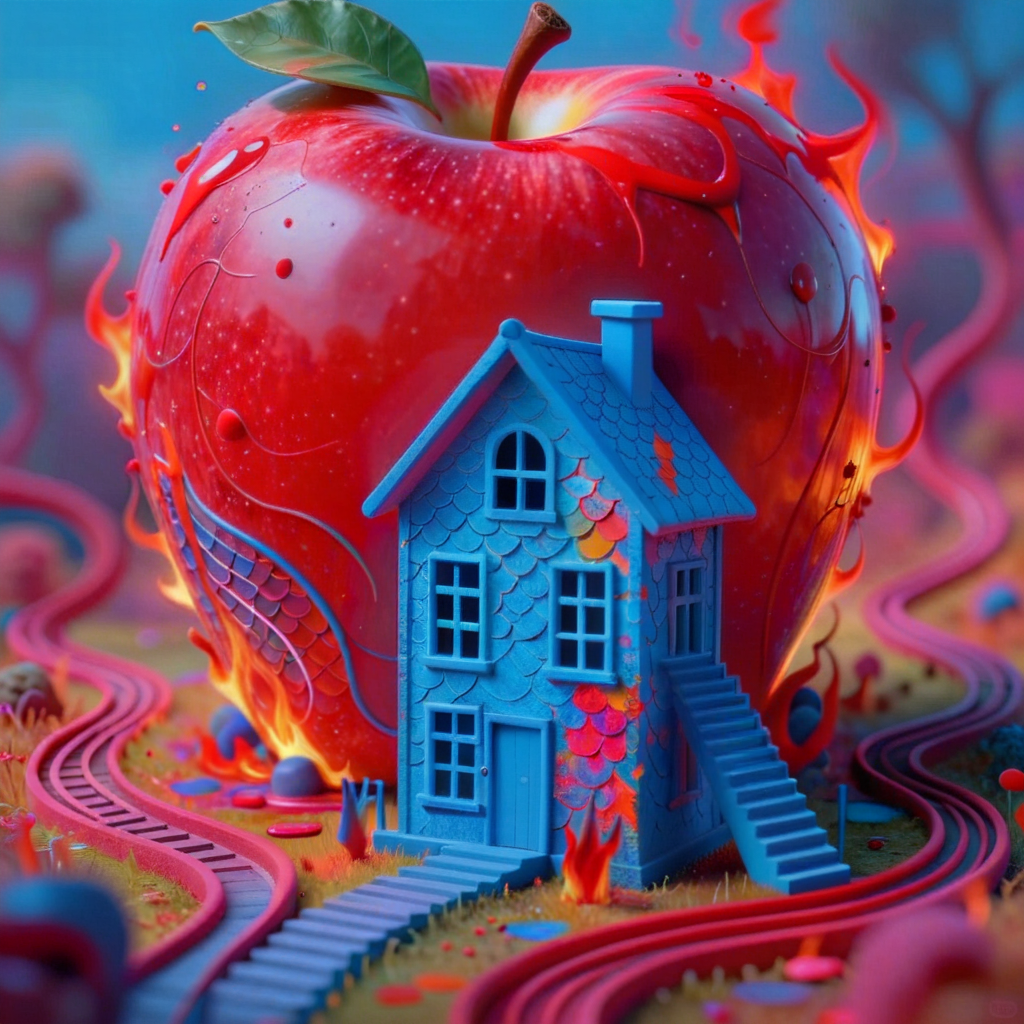

In [33]:
result.images[0] 